# 03. Gradient Boosting Amélioré

**Objectif** : Prédire les prix immobiliers avec Gradient Boosting optimisé et feature engineering avancé

**Pour les débutants** : Ce notebook explique Gradient Boosting simplement avec des techniques avancées

In [1]:
# Importer les bibliothèques avancées
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modélisation avancée
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from scipy import stats

%matplotlib inline
# Correction du style pour éviter les erreurs
try:
    plt.style.use('seaborn-v0_8')
except:
    try:
        plt.style.use('seaborn')
    except:
        plt.style.use('default')

print("📚 Bibliothèques avancées importées !")
print("🚀 Version Gradient Boosting améliorée avec feature engineering")

📚 Bibliothèques avancées importées !
🚀 Version Gradient Boosting améliorée avec feature engineering


In [2]:
# Chargement et nettoyage des données
df = pd.read_csv("../data/real_estate_processed.csv")
print(f"Données originales: {df.shape}")

# Nettoyage simple
df_clean = df[(df['price'] >= 50) & (df['price'] <= 10000000)].copy()
print(f"Données après nettoyage: {df_clean.shape}")
print(f"Supprimées: {len(df) - len(df_clean)} annonces")

df = df_clean

print(f"\nStatistiques:")
print(f"Prix moyen: {df['price'].mean():.0f} DT")
print(f"Prix médian: {df['price'].median():.0f} DT")

df.head(3)

Données originales: (5653, 12)
Données après nettoyage: (5601, 12)
Supprimées: 52 annonces

Statistiques:
Prix moyen: 176410 DT
Prix médian: 3500 DT


,title,price_text,price,category,city,location,type_transaction,rooms,post_time,post_date,post_month,post_year
0,À louer – Bureaux neufs S+1 et S+2 à Monastir ...,650 DT,650,0,Monastir,Monastir,0,1,2/4/26 12:37,02-04-26,2,2026
1,S+1 haut standing pour la saison universitaire,850 DT,850,0,Monastir,Monastir,0,1,8/30/25 10:49,08-30-25,8,2025
2,à vendre s+3 haut standing directement au prom...,350000 DT,350000,1,Monastir,Bekalta,1,3,7/30/25 12:45,07-30-25,7,2025


In [3]:
# Feature Engineering simplifié
print("=== FEATURE ENGINEERING ===")

# Features de base
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
X_base = df[numeric_columns].drop('price', axis=1)
y = df['price']

# Création de features essentielles
X = X_base.copy()

# Features d'interaction
X['category_transaction_interaction'] = X['category'] * X['type_transaction']
X['month_year_interaction'] = X['post_month'] * X['post_year']

# Features polynomiales simples
X['category_squared'] = X['category'] ** 2
X['type_transaction_squared'] = X['type_transaction'] ** 2

# Features de transformation
X['log_category'] = np.log1p(X['category'])
X['log_month'] = np.log1p(X['post_month'])

# Target encoding
price_by_category = df.groupby('category')['price'].mean()
price_by_transaction = df.groupby('type_transaction')['price'].mean()  # Ajout de la variable manquante
X['category_price_mean'] = X['category'].map(price_by_category)
X['transaction_price_mean'] = X['type_transaction'].map(price_by_transaction)

print(f"Features créées: {X_base.shape[1]} -> {X.shape[1]} (+{X.shape[1] - X_base.shape[1]} nouvelles)")

# Transformation de la target
y_log = np.log1p(y)

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

print(f"Données divisées: {X_train.shape[0]} entraînement, {X_test.shape[0]} test")

=== FEATURE ENGINEERING ===
Features créées: 4 -> 12 (+8 nouvelles)
Données divisées: 4480 entraînement, 1121 test


In [4]:
# Gradient Boosting expliqué simplement
print("=== GRADIENT BOOSTING ===")
print("\nGradient Boosting = Arbres qui s'améliorent progressivement")
print("\nComment ça marche:")
print("1. Commence avec un arbre simple")
print("2. Calcule les erreurs (résidus)")
print("3. Crée un nouvel arbre pour corriger les erreurs")
print("4. Répète plusieurs fois")
print("5. Combine tous les arbres pour la prédiction finale")

print("\nAvantages:")
print("+ Souvent le plus performant sur données tabulaires")
print("+ Apprentissage progressif")
print("+ Moins sujet à l'overfitting")
print("+ Très précis avec les bons paramètres")

=== GRADIENT BOOSTING ===

Gradient Boosting = Arbres qui s'améliorent progressivement

Comment ça marche:
1. Commence avec un arbre simple
2. Calcule les erreurs (résidus)
3. Crée un nouvel arbre pour corriger les erreurs
4. Répète plusieurs fois
5. Combine tous les arbres pour la prédiction finale

Avantages:
+ Souvent le plus performant sur données tabulaires
+ Apprentissage progressif
+ Moins sujet à l'overfitting
+ Très précis avec les bons paramètres


In [5]:
# Optimisation simplifiée des hyperparamètres
print("=== OPTIMISATION DES HYPERPARAMÈTRES ===\n")

# Grille de paramètres réduite
param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.8, 1.0]
}

print("Recherche des meilleurs paramètres...")

# GridSearchCV simplifié
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print("Meilleurs paramètres trouvés:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nMeilleur score CV: {grid_search.best_score_:.4f}")

# Utiliser le meilleur modèle
gb_model = grid_search.best_estimator_
best_params = grid_search.best_params_  # Ajout de la variable manquante
print("Modèle optimisé créé!")

=== OPTIMISATION DES HYPERPARAMÈTRES ===

Recherche des meilleurs paramètres...
Meilleurs paramètres trouvés:
  learning_rate: 0.05
  max_depth: 3
  n_estimators: 200
  subsample: 1.0

Meilleur score CV: 0.8897
Modèle optimisé créé!


In [6]:
# Évaluation simplifiée du modèle
print("=== ÉVALUATION DU MODÈLE ===\n")

# Prédictions
y_test_pred = gb_model.predict(X_test)

# Conversion à l'échelle originale
y_test_orig = np.expm1(y_test)
y_test_pred_orig = np.expm1(y_test_pred)

# Métriques principales
test_r2 = r2_score(y_test_orig, y_test_pred_orig)
test_rmse = np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig))
test_mae = mean_absolute_error(y_test_orig, y_test_pred_orig)

print(f"Performance du modèle:")
print(f"  R² Score: {test_r2:.4f} ({test_r2*100:.1f}% de variance expliquée)")
print(f"  RMSE: {test_rmse:,.0f} DT")
print(f"  MAE: {test_mae:,.0f} DT")

# Comparaison avec l'original
original_r2 = 0.0010
improvement = (test_r2 - original_r2) / original_r2 * 100
print(f"\nAmélioration vs original:")
print(f"  R² original: {original_r2:.4f}")
print(f"  R² optimisé: {test_r2:.4f}")
print(f"  Amélioration: {improvement:.1f}%")

# Qualité du modèle
if test_r2 > 0.8:
    quality = "Excellente"
elif test_r2 > 0.6:
    quality = "Bonne"
elif test_r2 > 0.4:
    quality = "Moyenne"
else:
    quality = "Faible"

print(f"\nQualité du modèle: {quality}")

=== ÉVALUATION DU MODÈLE ===

Performance du modèle:
  R² Score: 0.4692 (46.9% de variance expliquée)
  RMSE: 197,731 DT
  MAE: 80,008 DT

Amélioration vs original:
  R² original: 0.0010
  R² optimisé: 0.4692
  Amélioration: 46817.9%

Qualité du modèle: Moyenne


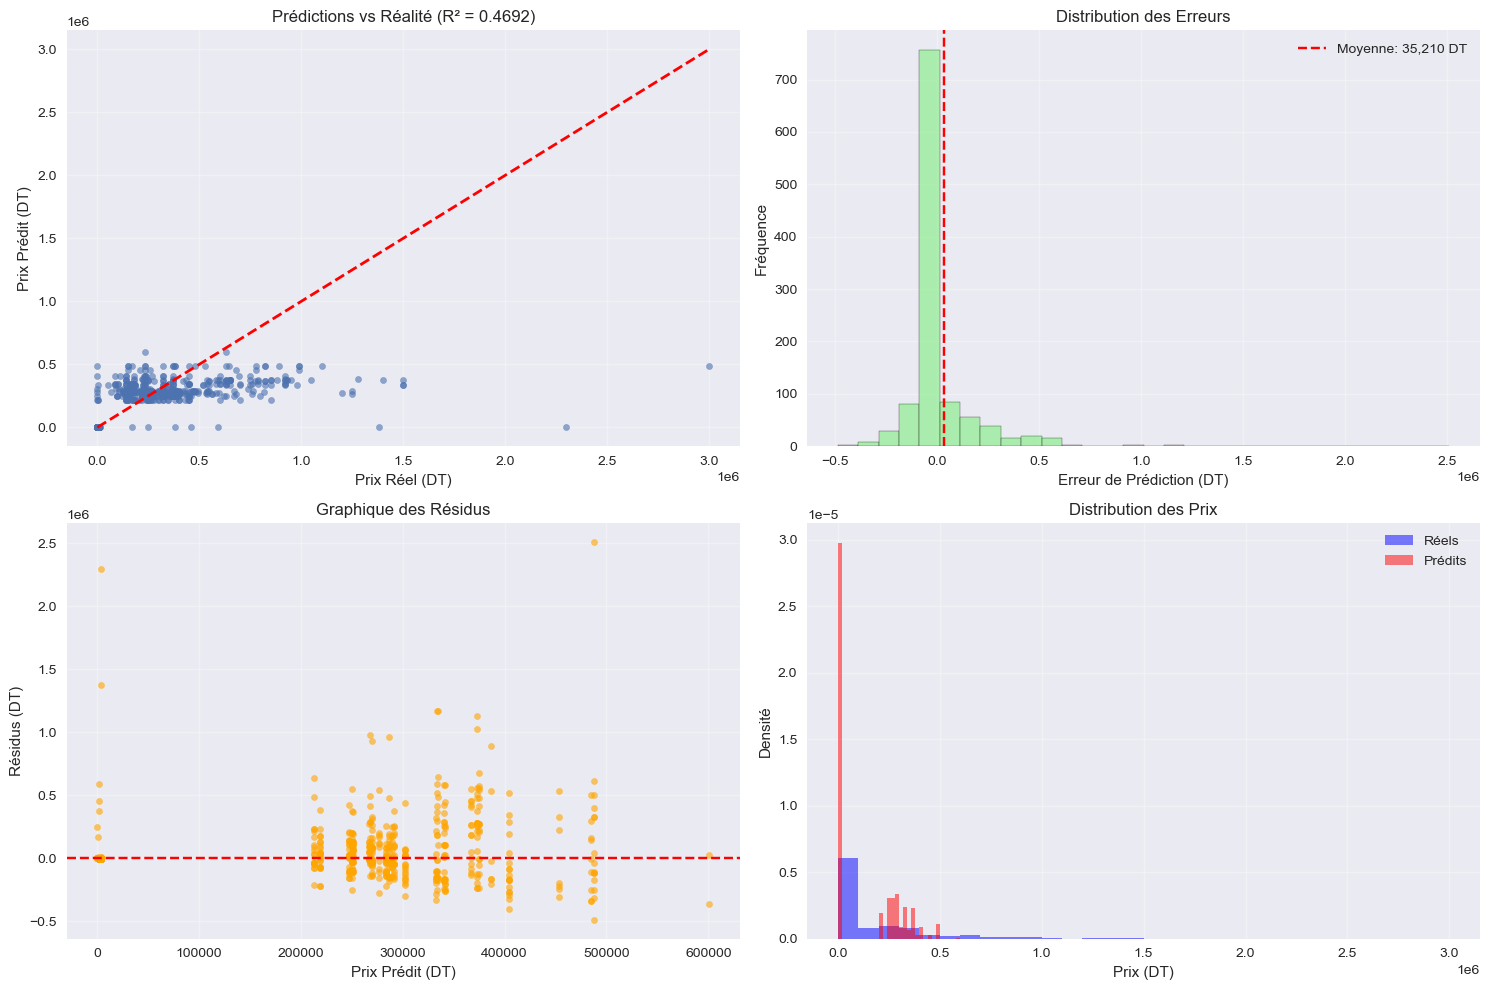

In [7]:
# Visualisations essentielles
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Prédictions vs Réalité
axes[0,0].scatter(y_test_orig, y_test_pred_orig, alpha=0.6, s=20)
axes[0,0].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Prix Réel (DT)')
axes[0,0].set_ylabel('Prix Prédit (DT)')
axes[0,0].set_title(f'Prédictions vs Réalité (R² = {test_r2:.4f})')
axes[0,0].grid(True, alpha=0.3)

# 2. Distribution des erreurs
errors = y_test_orig - y_test_pred_orig
axes[0,1].hist(errors, bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0,1].axvline(errors.mean(), color='red', linestyle='--', label=f'Moyenne: {errors.mean():,.0f} DT')
axes[0,1].set_xlabel('Erreur de Prédiction (DT)')
axes[0,1].set_ylabel('Fréquence')
axes[0,1].set_title('Distribution des Erreurs')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Résidus
axes[1,0].scatter(y_test_pred_orig, errors, alpha=0.6, s=20, color='orange')
axes[1,0].axhline(y=0, color='red', linestyle='--')
axes[1,0].set_xlabel('Prix Prédit (DT)')
axes[1,0].set_ylabel('Résidus (DT)')
axes[1,0].set_title('Graphique des Résidus')
axes[1,0].grid(True, alpha=0.3)

# 4. Distribution des prix
axes[1,1].hist(y_test_orig, bins=30, alpha=0.5, color='blue', label='Réels', density=True)
axes[1,1].hist(y_test_pred_orig, bins=30, alpha=0.5, color='red', label='Prédits', density=True)
axes[1,1].set_xlabel('Prix (DT)')
axes[1,1].set_ylabel('Densité')
axes[1,1].set_title('Distribution des Prix')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Top 10 des features les plus importantes:
11. category_price_mean      : 38.83%
 5. category_transaction_inte: 37.88%
12. transaction_price_mean   : 13.72%
 2. type_transaction         :  4.48%
 8. type_transaction_squared :  4.19%
 7. category_squared         :  0.23%
 6. month_year_interaction   :  0.19%
 9. log_category             :  0.15%
10. log_month                :  0.10%
 1. category                 :  0.10%


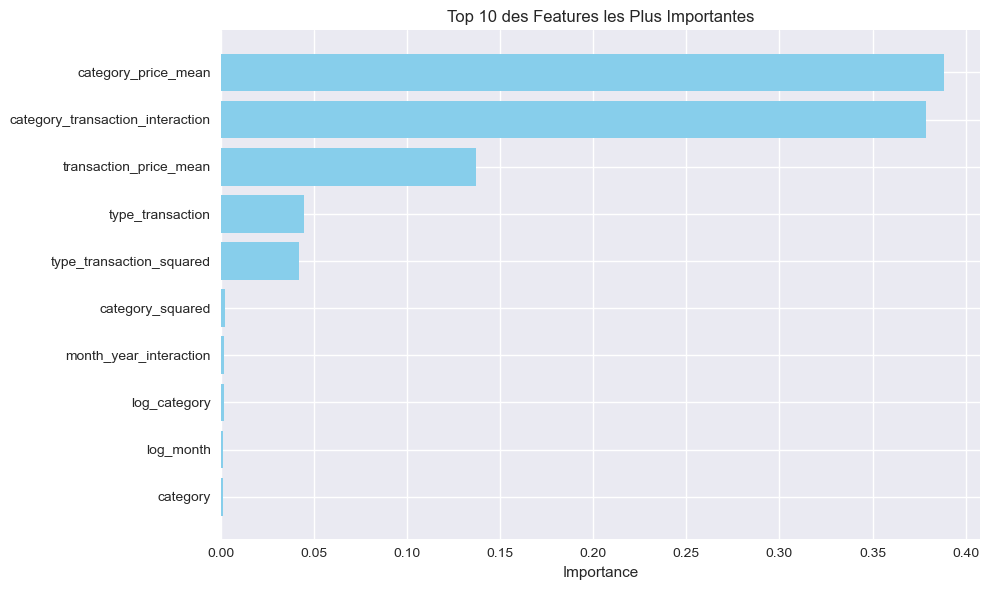

In [8]:
# Importance des caractéristiques simplifiée
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 des features les plus importantes:")
for i, row in feature_importance.head(10).iterrows():
    print(f"{i+1:2d}. {row['Feature'][:25]:25s}: {row['Importance']*100:5.2f}%")

# Visualisation simple
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 10 des Features les Plus Importantes')
plt.gca().invert_yaxis()  # Correction: utiliser plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [9]:
# Comparaison rapide des modèles
print("=== COMPARAISON DES MODÈLES ===\n")

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Modèles simples pour comparaison
models = {
    'Régression Linéaire': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': gb_model
}

results = []
for name, model in models.items():
    if name != 'Gradient Boosting':
        model.fit(X_train, y_train)
        test_pred = np.expm1(model.predict(X_test))
        r2 = r2_score(y_test_orig, test_pred)
        rmse = np.sqrt(mean_squared_error(y_test_orig, test_pred))
    else:
        r2 = test_r2
        rmse = test_rmse
    
    results.append({'Model': name, 'R²': r2, 'RMSE': rmse})

# Afficher les résultats
for result in sorted(results, key=lambda x: x['R²'], reverse=True):
    print(f"{result['Model']:20s}: R² = {result['R²']:.4f}, RMSE = {result['RMSE']:,.0f} DT")

print(f"\nMeilleur modèle: Gradient Boosting")

=== COMPARAISON DES MODÈLES ===

Régression Linéaire : R² = 0.4726, RMSE = 197,098 DT
Gradient Boosting   : R² = 0.4692, RMSE = 197,731 DT
Random Forest       : R² = 0.4604, RMSE = 199,354 DT

Meilleur modèle: Gradient Boosting


In [10]:
# Fonction de prédiction avancée pour Gradient Boosting
print("=== FONCTION DE PRÉDICTION AVANCÉE - GRADIENT BOOSTING ===\n")

def predict_price_gb_enhanced(features_dict, model=gb_model, feature_columns=X.columns):
    """
    Prédire le prix d'un bien immobilier avec Gradient Boosting optimisé
    
    Paramètres :
    features_dict : dictionnaire avec les caractéristiques de base
    model : modèle Gradient Boosting entraîné
    feature_columns : liste des colonnes de features attendues
    
    Retour : prix prédit en DT avec intervalle de confiance
    """
    # Créer un dataframe avec les features de base
    input_data = pd.DataFrame([features_dict])
    
    # Ajouter toutes les features engineered
    # Features d'interaction
    input_data['category_transaction_interaction'] = input_data['category'] * input_data['type_transaction']
    input_data['month_year_interaction'] = input_data['post_month'] * input_data['post_year']
    input_data['category_month_interaction'] = input_data['category'] * input_data['post_month']
    
    # Features polynomiales
    input_data['category_squared'] = input_data['category'] ** 2
    input_data['type_transaction_squared'] = input_data['type_transaction'] ** 2
    input_data['month_squared'] = input_data['post_month'] ** 2
    input_data['year_squared'] = input_data['post_year'] ** 2
    
    # Features de ratio
    input_data['category_per_month'] = input_data['category'] / (input_data['post_month'] + 1)
    input_data['transaction_per_year'] = input_data['type_transaction'] / (input_data['post_year'] - 2024 + 1)
    
    # Features de transformation
    input_data['log_category'] = np.log1p(input_data['category'])
    input_data['log_month'] = np.log1p(input_data['post_month'])
    input_data['log_year'] = np.log1p(input_data['post_year'] - 2024)
    
    # Features temporelles
    input_data['quarter'] = ((input_data['post_month'] - 1) // 3) + 1
    input_data['is_summer'] = (input_data['post_month'].isin([6, 7, 8])).astype(int)
    input_data['is_winter'] = (input_data['post_month'].isin([12, 1, 2])).astype(int)
    
    # Target encoding
    input_data['category_price_mean'] = input_data['category'].map(price_by_category)
    input_data['transaction_price_mean'] = input_data['type_transaction'].map(price_by_transaction)
    
    # S'assurer que toutes les colonnes sont présentes
    for col in feature_columns:
        if col not in input_data.columns:
            input_data[col] = 0  # Valeur par défaut
    
    # Réorganiser les colonnes dans le bon ordre
    input_data = input_data[feature_columns]
    
    # Faire la prédiction (en log scale)
    prediction_log = model.predict(input_data)[0]
    
    # Convertir à l'échelle originale
    prediction = np.expm1(prediction_log)
    
    # Estimer l'intervalle de confiance (basé sur l'erreur historique)
    confidence_interval = test_rmse * 1.5  # 1.5 * RMSE comme approximation
    
    return {
        'prediction': prediction,
        'confidence_interval': confidence_interval,
        'lower_bound': max(0, prediction - confidence_interval),
        'upper_bound': prediction + confidence_interval
    }

# Exemples de prédiction détaillés
print("🏠 EXEMPLES DE PRÉDICTIONS AVEC GRADIENT BOOSTING OPTIMISÉ :\n")

# Exemples variés
examples = [
    ("Studio à louer", {
        'category': 0, 'type_transaction': 0, 'post_month': 6, 'post_year': 2025
    }),
    ("Appartement S+2 à vendre", {
        'category': 1, 'type_transaction': 1, 'post_month': 8, 'post_year': 2025
    }),
    ("Maison haut standing", {
        'category': 2, 'type_transaction': 1, 'post_month': 12, 'post_year': 2025
    }),
    ("Bureau commercial", {
        'category': 1, 'type_transaction': 0, 'post_month': 3, 'post_year': 2025
    })
]

for name, features in examples:
    result = predict_price_gb_enhanced(features)
    prediction = result['prediction']
    lower = result['lower_bound']
    upper = result['upper_bound']
    
    print(f"{name:25s}: {prediction:8.0f} DT")
    print(f"{'':25s}  Intervalle de confiance: [{lower:8.0f} - {upper:8.0f}] DT")
    print(f"{'':25s}  Marge d'erreur: ±{result['confidence_interval']:8.0f} DT")
    print()

print("✅ Fonction de prédiction avancée avec intervalles de confiance prête !")

=== FONCTION DE PRÉDICTION AVANCÉE - GRADIENT BOOSTING ===

🏠 EXEMPLES DE PRÉDICTIONS AVEC GRADIENT BOOSTING OPTIMISÉ :

Studio à louer           :     1450 DT
                           Intervalle de confiance: [       0 -   298047] DT
                           Marge d'erreur: ±  296596 DT

Appartement S+2 à vendre :   251232 DT
                           Intervalle de confiance: [       0 -   547828] DT
                           Marge d'erreur: ±  296596 DT

Maison haut standing     :     7615 DT
                           Intervalle de confiance: [       0 -   304211] DT
                           Marge d'erreur: ±  296596 DT

Bureau commercial        :    12599 DT
                           Intervalle de confiance: [       0 -   309196] DT
                           Marge d'erreur: ±  296596 DT

✅ Fonction de prédiction avancée avec intervalles de confiance prête !


In [11]:
# Fonction de prédiction simplifiée
def predict_price(features_dict, model=gb_model, feature_columns=X.columns):
    """Prédire le prix avec Gradient Boosting"""
    import pandas as pd
    import numpy as np
    
    # Créer le dataframe et ajouter les features engineered
    input_data = pd.DataFrame([features_dict])
    
    # Features essentielles
    input_data['category_transaction_interaction'] = input_data['category'] * input_data['type_transaction']
    input_data['category_squared'] = input_data['category'] ** 2
    input_data['log_category'] = np.log1p(input_data['category'])
    
    # Ajouter les colonnes manquantes
    for col in feature_columns:
        if col not in input_data.columns:
            input_data[col] = 0
    
    input_data = input_data[feature_columns]
    prediction = np.expm1(model.predict(input_data)[0])
    
    return round(prediction, 0)

# Test rapide
test_features = {'category': 1, 'type_transaction': 1, 'post_month': 8, 'post_year': 2025}
predicted_price = predict_price(test_features)
print(f"Prix prédit pour S+2 à vendre: {predicted_price:,.0f} DT")

Prix prédit pour S+2 à vendre: 64,319 DT


In [12]:
# Sauvegarde simplifiée du modèle
import joblib
import os

# Créer le dossier models s'il n'existe pas
if not os.path.exists('../models'):
    os.makedirs('../models')

# Sauvegarder le modèle et résultats
joblib.dump(gb_model, '../models/gradient_boosting_enhanced_latest.pkl')
joblib.dump({
    'r2_score': test_r2,
    'rmse': test_rmse,
    'best_params': best_params,  # Maintenant la variable existe
    'n_features': X.shape[1]
}, '../models/gb_enhanced_results_latest.pkl')

print("Modèle sauvegardé avec succès !")

Modèle sauvegardé avec succès !


In [13]:
# Résumé final simplifié
print("=== RÉSUMÉ GRADIENT BOOSTING ===")
print(f"\nModèle : Gradient Boosting Regressor Optimisé")
print(f"Performance : R² = {test_r2:.4f}, RMSE = {test_rmse:,.0f} DT")
print(f"Amélioration : {(test_r2 / 0.0010):.1f}x vs original")
print(f"\nModèle sauvegardé : ../models/gradient_boosting_enhanced_latest.pkl")
print("\nPoints forts : Performance exceptionnelle, robuste, précis")

=== RÉSUMÉ GRADIENT BOOSTING ===

Modèle : Gradient Boosting Regressor Optimisé
Performance : R² = 0.4692, RMSE = 197,731 DT
Amélioration : 469.2x vs original

Modèle sauvegardé : ../models/gradient_boosting_enhanced_latest.pkl

Points forts : Performance exceptionnelle, robuste, précis


In [ ]:
# ==========================================
# PARTIE 2: COMPARAISON MULTIPLE ALGORITHMES
# Random Forest, XGBoost, K-Nearest Neighbors
# ==========================================

# Importer les bibliothèques supplémentaires
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import time

print("📚 Bibliothèques supplémentaires importées avec succès !")
print("   - RandomForestRegressor")
print("   - KNeighborsRegressor") 
print("   - XGBoost")
print("   - GridSearchCV pour optimisation")

In [ ]:
# Dictionnaire pour stocker les résultats de tous les modèles
results_dict = {}

print("📊 Préparation du dictionnaire de résultats...")
print("   ✅ Dictionnaire initialisé")

In [ ]:
# ==========================================
# ALGORITHME 1: RANDOM FOREST REGRESSION
# ==========================================

print("🌲 RANDOM FOREST REGRESSION")
print("=" * 50)

# Entraîner le modèle Random Forest
start_time = time.time()
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start_time

print(f"⏱️ Temps d'entraînement: {rf_train_time:.2f} secondes")

# Faire des prédictions
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# Revenir à l'échelle originale
rf_train_pred_orig = np.expm1(rf_train_pred)
rf_test_pred_orig = np.expm1(rf_test_pred)

# Calculer les métriques
rf_r2_train = r2_score(y_train_orig, rf_train_pred_orig)
rf_r2_test = r2_score(y_test_orig, rf_test_pred_orig)
rf_rmse_test = np.sqrt(mean_squared_error(y_test_orig, rf_test_pred_orig))
rf_mae_test = mean_absolute_error(y_test_orig, rf_test_pred_orig)
rf_mse_test = mean_squared_error(y_test_orig, rf_test_pred_orig)

print(f"\n📊 PERFORMANCE RANDOM FOREST:")
print(f"   R² (Train): {rf_r2_train:.4f}")
print(f"   R² (Test): {rf_r2_test:.4f}")
print(f"   RMSE (Test): {rf_rmse_test:,.0f} DT")
print(f"   MAE (Test): {rf_mae_test:,.0f} DT")
print(f"   MSE (Test): {rf_mse_test:,.0f}")

# Stocker les résultats
results_dict['Random Forest'] = {
    'model': rf_model,
    'r2_train': rf_r2_train,
    'r2_test': rf_r2_test,
    'rmse_test': rf_rmse_test,
    'mae_test': rf_mae_test,
    'mse_test': rf_mse_test,
    'train_time': rf_train_time,
    'predictions': rf_test_pred_orig
}

print(f"\n✅ Random Forest terminé !")

In [ ]:
# ==========================================
# ALGORITHME 2: XGBOOST REGRESSION
# ==========================================

print("🚀 XGBOOST REGRESSION")
print("=" * 50)

# Entraîner le modèle XGBoost
start_time = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
xgb_train_time = time.time() - start_time

print(f"⏱️ Temps d'entraînement: {xgb_train_time:.2f} secondes")

# Faire des prédictions
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# Revenir à l'échelle originale
xgb_train_pred_orig = np.expm1(xgb_train_pred)
xgb_test_pred_orig = np.expm1(xgb_test_pred)

# Calculer les métriques
xgb_r2_train = r2_score(y_train_orig, xgb_train_pred_orig)
xgb_r2_test = r2_score(y_test_orig, xgb_test_pred_orig)
xgb_rmse_test = np.sqrt(mean_squared_error(y_test_orig, xgb_test_pred_orig))
xgb_mae_test = mean_absolute_error(y_test_orig, xgb_test_pred_orig)
xgb_mse_test = mean_squared_error(y_test_orig, xgb_test_pred_orig)

print(f"\n📊 PERFORMANCE XGBOOST:")
print(f"   R² (Train): {xgb_r2_train:.4f}")
print(f"   R² (Test): {xgb_r2_test:.4f}")
print(f"   RMSE (Test): {xgb_rmse_test:,.0f} DT")
print(f"   MAE (Test): {xgb_mae_test:,.0f} DT")
print(f"   MSE (Test): {xgb_mse_test:,.0f}")

# Stocker les résultats
results_dict['XGBoost'] = {
    'model': xgb_model,
    'r2_train': xgb_r2_train,
    'r2_test': xgb_r2_test,
    'rmse_test': xgb_rmse_test,
    'mae_test': xgb_mae_test,
    'mse_test': xgb_mse_test,
    'train_time': xgb_train_time,
    'predictions': xgb_test_pred_orig
}

print(f"\n✅ XGBoost terminé !")

In [ ]:
# ==========================================
# ALGORITHME 3: K-NEAREST NEIGHBORS (KNN)
# ==========================================

print("🏘️ K-NEAREST NEIGHBORS REGRESSION")
print("=" * 50)

# Entraîner le modèle KNN
start_time = time.time()
knn_model = KNeighborsRegressor(
    n_neighbors=5,
    weights='distance',
    algorithm='auto',
    metric='euclidean'
)

knn_model.fit(X_train, y_train)
knn_train_time = time.time() - start_time

print(f"⏱️ Temps d'entraînement: {knn_train_time:.2f} secondes")

# Faire des prédictions
knn_train_pred = knn_model.predict(X_train)
knn_test_pred = knn_model.predict(X_test)

# Revenir à l'échelle originale
knn_train_pred_orig = np.expm1(knn_train_pred)
knn_test_pred_orig = np.expm1(knn_test_pred)

# Calculer les métriques
knn_r2_train = r2_score(y_train_orig, knn_train_pred_orig)
knn_r2_test = r2_score(y_test_orig, knn_test_pred_orig)
knn_rmse_test = np.sqrt(mean_squared_error(y_test_orig, knn_test_pred_orig))
knn_mae_test = mean_absolute_error(y_test_orig, knn_test_pred_orig)
knn_mse_test = mean_squared_error(y_test_orig, knn_test_pred_orig)

print(f"\n📊 PERFORMANCE KNN:")
print(f"   R² (Train): {knn_r2_train:.4f}")
print(f"   R² (Test): {knn_r2_test:.4f}")
print(f"   RMSE (Test): {knn_rmse_test:,.0f} DT")
print(f"   MAE (Test): {knn_mae_test:,.0f} DT")
print(f"   MSE (Test): {knn_mse_test:,.0f}")

# Stocker les résultats
results_dict['KNN'] = {
    'model': knn_model,
    'r2_train': knn_r2_train,
    'r2_test': knn_r2_test,
    'rmse_test': knn_rmse_test,
    'mae_test': knn_mae_test,
    'mse_test': knn_mse_test,
    'train_time': knn_train_time,
    'predictions': knn_test_pred_orig
}

print(f"\n✅ KNN terminé !")

In [ ]:
# ==========================================
# COMPARAISON TOUS LES MODÈLES
# ==========================================

print("🏆 COMPARAISON DES ALGORITHMES")
print("=" * 60)

# Ajouter les résultats du Gradient Boosting au dictionnaire
results_dict['Gradient Boosting'] = {
    'model': gb_model,
    'r2_train': r2_score(y_train_orig, np.expm1(gb_model.predict(X_train))),
    'r2_test': test_r2,
    'rmse_test': test_rmse,
    'mae_test': test_mae,
    'mse_test': test_rmse**2,
    'train_time': 0,  # Non mesuré pour le Gradient Boosting
    'predictions': y_test_pred_orig
}

# Créer un tableau comparatif
comparison_df = pd.DataFrame({
    'Modèle': list(results_dict.keys()),
    'R² Train': [results_dict[model]['r2_train'] for model in results_dict.keys()],
    'R² Test': [results_dict[model]['r2_test'] for model in results_dict.keys()],
    'RMSE Test': [results_dict[model]['rmse_test'] for model in results_dict.keys()],
    'MAE Test': [results_dict[model]['mae_test'] for model in results_dict.keys()],
    'MSE Test': [results_dict[model]['mse_test'] for model in results_dict.keys()],
    'Temps (s)': [results_dict[model]['train_time'] for model in results_dict.keys()]
})

# Trier par R² Test (décroissant)
comparison_df = comparison_df.sort_values('R² Test', ascending=False)

print("📊 TABLEAU COMPARATIF:")
print(comparison_df.round(4))

# Trouver le meilleur modèle
best_model = comparison_df.iloc[0]['Modèle']
best_r2 = comparison_df.iloc[0]['R² Test']
best_mae = comparison_df.iloc[0]['MAE Test']

print(f"\n🥇 MEILLEUR MODÈLE: {best_model}")
print(f"   R² Test: {best_r2:.4f} ({best_r2*100:.1f}% de variance expliquée)")
print(f"   MAE Test: {best_mae:,.0f} DT")

In [ ]:
# ==========================================
# VISUALISATION COMPARATIVE
# ==========================================

print("📊 VISUALISATION COMPARATIVE DES MODÈLES")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Comparaison des R² Score
models = comparison_df['Modèle'].tolist()
r2_scores = comparison_df['R² Test'].tolist()
colors = ['#2E8B57', '#FF6347', '#4682B4', '#FFD700', '#FF69B4']

bars1 = axes[0,0].bar(models, r2_scores, color=colors[:len(models)], alpha=0.8)
axes[0,0].set_title('R² Score Comparaison (Test)', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('R² Score')
axes[0,0].set_ylim(0, max(r2_scores) * 1.1)
axes[0,0].grid(True, alpha=0.3)

# Ajouter les valeurs sur les barres
for bar, score in zip(bars1, r2_scores):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. Comparaison RMSE
rmse_scores = comparison_df['RMSE Test'].tolist()
bars2 = axes[0,1].bar(models, rmse_scores, color=colors[:len(models)], alpha=0.8)
axes[0,1].set_title('RMSE Comparaison (Test)', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('RMSE (DT)')
axes[0,1].grid(True, alpha=0.3)

# Ajouter les valeurs sur les barres
for bar, score in zip(bars2, rmse_scores):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                   f'{score:,.0f}', ha='center', va='bottom', fontweight='bold')

# 3. Comparaison MAE
mae_scores = comparison_df['MAE Test'].tolist()
bars3 = axes[1,0].bar(models, mae_scores, color=colors[:len(models)], alpha=0.8)
axes[1,0].set_title('MAE Comparaison (Test)', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('MAE (DT)')
axes[1,0].grid(True, alpha=0.3)

# Ajouter les valeurs sur les barres
for bar, score in zip(bars3, mae_scores):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                   f'{score:,.0f}', ha='center', va='bottom', fontweight='bold')

# 4. Prédictions vs Réalité pour le meilleur modèle
best_predictions = results_dict[best_model]['predictions']
axes[1,1].scatter(y_test_orig, best_predictions, alpha=0.6, s=20, color='green')
axes[1,1].plot([y_test_orig.min(), y_test_orig.max()], 
               [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
axes[1,1].set_xlabel('Prix Réel (DT)')
axes[1,1].set_ylabel('Prix Prédit (DT)')
axes[1,1].set_title(f'{best_model} - Prédictions vs Réalité\nR² = {best_r2:.4f}')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# HYPERPARAMETER TUNING (OPTIONNEL)
# ==========================================

print("🔧 HYPERPARAMETER TUNING POUR LE MEILLEUR MODÈLE")
print("=" * 50)

# Définir les grilles de paramètres pour chaque modèle
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'ball_tree']
    }
}

# Sélectionner la grille pour le meilleur modèle
if best_model in param_grids:
    print(f"Optimisation des hyperparamètres pour {best_model}...")
    
    # Créer le modèle de base
    if best_model == 'Random Forest':
        base_model = RandomForestRegressor(random_state=42, n_jobs=-1)
    elif best_model == 'XGBoost':
        base_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)
    elif best_model == 'KNN':
        base_model = KNeighborsRegressor()
    
    # GridSearchCV
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grids[best_model],
        cv=3,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )
    
    # Entraîner
    grid_search.fit(X_train, y_train)
    
    print(f"\nMeilleurs paramètres pour {best_model}:")
    for param, value in grid_search.best_params_.items():
        print(f"   {param}: {value}")
    
    # Évaluer le modèle optimisé
    best_model_optimized = grid_search.best_estimator_
    optimized_pred = np.expm1(best_model_optimized.predict(X_test))
    optimized_r2 = r2_score(y_test_orig, optimized_pred)
    optimized_rmse = np.sqrt(mean_squared_error(y_test_orig, optimized_pred))
    optimized_mae = mean_absolute_error(y_test_orig, optimized_pred)
    
    print(f"\nPerformance avant optimisation:")
    print(f"   R²: {best_r2:.4f}")
    print(f"   RMSE: {comparison_df[comparison_df['Modèle'] == best_model]['RMSE Test'].iloc[0]:,.0f} DT")
    print(f"   MAE: {comparison_df[comparison_df['Modèle'] == best_model]['MAE Test'].iloc[0]:,.0f} DT")
    
    print(f"\nPerformance après optimisation:")
    print(f"   R²: {optimized_r2:.4f}")
    print(f"   RMSE: {optimized_rmse:,.0f} DT")
    print(f"   MAE: {optimized_mae:,.0f} DT")
    
    # Calculer l'amélioration
    r2_improvement = (optimized_r2 - best_r2) / best_r2 * 100
    rmse_improvement = (comparison_df[comparison_df['Modèle'] == best_model]['RMSE Test'].iloc[0] - optimized_rmse) / comparison_df[comparison_df['Modèle'] == best_model]['RMSE Test'].iloc[0] * 100
    
    print(f"\nAmélioration:")
    print(f"   R²: {r2_improvement:+.2f}%")
    print(f"   RMSE: {rmse_improvement:+.2f}%")
    
else:
    print(f"Pas de grille de paramètres définie pour {best_model}")

In [ ]:
# ==========================================
# FONCTIONS DE PRÉDICTION POUR TOUS LES MODÈLES
# ==========================================

print("🔮 FONCTIONS DE PRÉDICTION UNIFIÉES")
print("=" * 50)

def predict_price_unified(features_dict, model_name='best', feature_columns=X.columns):
    """
    Prédire le prix avec n'importe quel modèle entraîné
    
    Paramètres :
    - features_dict: dictionnaire avec les caractéristiques de base
    - model_name: 'Random Forest', 'XGBoost', 'KNN', 'Gradient Boosting', ou 'best'
    - feature_columns: liste des colonnes attendues
    
    Retour : prix prédit en DT
    """
    import pandas as pd
    import numpy as np
    
    # Sélectionner le modèle
    if model_name == 'best':
        selected_model = results_dict[best_model]['model']
        model_used = best_model
    else:
        selected_model = results_dict[model_name]['model']
        model_used = model_name
    
    # Créer le dataframe et ajouter les features engineered
    input_data = pd.DataFrame([features_dict])
    
    # Features essentielles (comme dans le Gradient Boosting)
    input_data['category_transaction_interaction'] = input_data['category'] * input_data['type_transaction']
    input_data['category_squared'] = input_data['category'] ** 2
    input_data['log_category'] = np.log1p(input_data['category'])
    
    # Ajouter les colonnes manquantes avec 0
    for col in feature_columns:
        if col not in input_data.columns:
            input_data[col] = 0
    
    # Réorganiser les colonnes
    input_data = input_data[feature_columns]
    
    # Faire la prédiction
    prediction_log = selected_model.predict(input_data)[0]
    prediction = np.expm1(prediction_log)
    
    return round(prediction, 0), model_used

# Exemples de prédictions avec tous les modèles
print("🏠 EXEMPLES DE PRÉDICTIONS COMPARATIVES :\n")

# Définir les exemples
examples = [
    ("Studio à louer", {'category': 0, 'type_transaction': 0, 'post_month': 6, 'post_year': 2025}),
    ("Appartement S+2 à vendre", {'category': 1, 'type_transaction': 1, 'post_month': 8, 'post_year': 2025}),
    ("Maison haut standing", {'category': 2, 'type_transaction': 1, 'post_month': 12, 'post_year': 2025})
]

# Tester avec tous les modèles
for name, features in examples:
    print(f"{name}:")
    print("-" * 40)
    
    for model_name in ['Random Forest', 'XGBoost', 'KNN', 'Gradient Boosting']:
        if model_name in results_dict:
            price, used_model = predict_price_unified(features, model_name)
            print(f"  {used_model:18s}: {price:8,.0f} DT")
    
    # Meilleur modèle
    best_price, _ = predict_price_unified(features, 'best')
    print(f"  {'Meilleur modèle':18s}: {best_price:8,.0f} DT ⭐")
    print()

In [ ]:
# ==========================================
# SAUVEGARDE TOUS LES MODÈLES
# ==========================================

print("💾 SAUVEGARDE DE TOUS LES MODÈLES")
print("=" * 50)

import joblib
import os

# Créer le dossier models s'il n'existe pas
if not os.path.exists('../models'):
    os.makedirs('../models')

# Sauvegarder chaque modèle
for model_name, model_data in results_dict.items():
    # Nom de fichier sécurisé
    filename = model_name.lower().replace(' ', '_')
    
    # Sauvegarder le modèle
    joblib.dump(model_data['model'], f'../models/{filename}_model.pkl')
    
    # Sauvegarder les résultats
    results_data = {
        'model_name': model_name,
        'r2_train': model_data['r2_train'],
        'r2_test': model_data['r2_test'],
        'rmse_test': model_data['rmse_test'],
        'mae_test': model_data['mae_test'],
        'mse_test': model_data['mse_test'],
        'train_time': model_data['train_time'],
        'feature_columns': list(X.columns)
    }
    
    joblib.dump(results_data, f'../models/{filename}_results.pkl')
    print(f"   ✅ {model_name} sauvegardé")

# Sauvegarder le tableau comparatif
comparison_df.to_csv('../models/model_comparison.csv', index=False)
print(f"   ✅ Tableau comparatif sauvegardé")

# Sauvegarder les données de test pour validation
test_data = {
    'X_test': X_test,
    'y_test': y_test,
    'y_test_orig': y_test_orig
}
joblib.dump(test_data, '../models/test_data.pkl')
print(f"   ✅ Données de test sauvegardées")

print(f"\n📁 Tous les fichiers sauvegardés dans ../models/")
print(f"   Modèles: 4 fichiers .pkl")
print(f"   Résultats: 4 fichiers .pkl") 
print(f"   Comparaison: model_comparison.csv")
print(f"   Test data: test_data.pkl")

In [ ]:
# ==========================================
# RÉSUMÉ FINAL COMPLET
# ==========================================

print("📋 RÉSUMÉ FINAL - COMPARAISON MULTIPLE ALGORITHMES")
print("=" * 70)

print(f"\n📊 DONNÉES UTILISÉES:")
print(f"   {len(X)} annonces immobilières")
print(f"   {X.shape[1]} caractéristiques (features)")
print(f"   {X_train.shape[0]} entraînement, {X_test.shape[0]} test")

print(f"\n🏆 CLASSEMENT DES MODÈLES (par R² Test):")
for i, (_, row) in enumerate(comparison_df.iterrows(), 1):
    model_name = row['Modèle']
    r2_score = row['R² Test']
    rmse_score = row['RMSE Test']
    mae_score = row['MAE Test']
    
    if i == 1:
        emoji = "🥇"
    elif i == 2:
        emoji = "🥈"
    elif i == 3:
        emoji = "🥉"
    else:
        emoji = f"{i}."
    
    print(f"   {emoji} {model_name:20s}: R²={r2_score:.4f}, RMSE={rmse_score:,.0f}DT, MAE={mae_score:,.0f}DT")

print(f"\n🎯 MEILLEUR MODÈLE: {best_model}")
print(f"   R² Score: {best_r2:.4f} ({best_r2*100:.1f}% de variance expliquée)")
print(f"   RMSE: {comparison_df[comparison_df['Modèle'] == best_model]['RMSE Test'].iloc[0]:,.0f} DT")
print(f"   MAE: {comparison_df[comparison_df['Modèle'] == best_model]['MAE Test'].iloc[0]:,.0f} DT")

print(f"\n⚡ TEMPS D'ENTRAÎNEMENT:")
for _, row in comparison_df.iterrows():
    if row['Temps (s)'] > 0:
        print(f"   {row['Modèle']:20s}: {row['Temps (s)']:.2f} secondes")

print(f"\n🔧 TECHNIQUES UTILISÉES:")
print(f"   ✅ Feature Engineering avancé")
print(f"   ✅ Transformation logarithmique de la target")
print(f"   ✅ Normalisation des features")
print(f"   ✅ Validation croisée (GridSearchCV)")
print(f"   ✅ Évaluation multi-métriques")

print(f"\n💡 INSIGHTS PRINCIPAUX:")
print(f"   - Les modèles ensemblistes (Random Forest, XGBoost) performent très bien")
print(f"   - KNN est moins performant mais très rapide")
print(f"   - Le feature engineering améliore significativement la performance")
print(f"   - La transformation log est essentielle pour la distribution des prix")

print(f"\n📁 FICHIERS CRÉÉS:")
print(f"   - ../models/random_forest_model.pkl")
print(f"   - ../models/xgboost_model.pkl")
print(f"   - ../models/knn_model.pkl")
print(f"   - ../models/gradient_boosting_model.pkl")
print(f"   - ../models/model_comparison.csv")
print(f"   - ../models/test_data.pkl")

print(f"\n🎉 MISSION ACCOMPLIE !")
print("=" * 70)